# Import & Load

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# hapus kolom berlebih

import csv

# Ganti jeneng file inputmu
input_file = 'ulasan-resto.csv'
# Jeneng file hasil sunat
output_file = 'ulasan-resto_new.csv'

try:
    with open(input_file, 'r', encoding='utf-8', errors='replace') as infile, \
         open(output_file, 'w', newline='', encoding='utf-8') as outfile:
        
        reader = csv.reader(infile)
        writer = csv.writer(outfile)
        
        count = 0
        for row in reader:
            # JURUS KUNCI: Mung njupuk 7 kolom pertama (indeks 0-6)
            # Kolom ke-8 (indeks 7) lan setersuse bakal dibuang
            row_sunat = row[:7] 
            
            writer.writerow(row_sunat)
            count += 1

    print("DONE")
    

except FileNotFoundError:
    print(f"Error: File '{input_file}'")
except Exception as e:
    print(f"Terjadi kesalahan: {e}")

DONE


In [3]:
df = pd.read_csv('ulasan-resto_new.csv')
df.head()

,restaurant_name,name,rating,review,items_ordered,purchase_date,user_since
0,"KFC, Pondok Chandra",NaN,5.0,Alhamdulillah mantap,NaN,NaN,NaN
1,"KFC, Pondok Chandra",Leny Widiowati,5.0,Alhamdulillah mantap,1 Pc Chicken + 1 Rice,26 January 2026,Gojek user since 30 October 2015
2,"KFC, Pondok Chandra",A**** R**** A*****,2.0,"Lama bgt, dan harusnya diproses dlu sblm drive...",Spaghetti Supreme - KFC Soup - 5 Pcs Chicken -...,20 January 2026,Gojek user since 31 March 2016
3,"KFC, Pondok Chandra",N*****,3.0,Request ayam paha atas malah di kasih ayam pah...,Chick Ball BBQ - Oriental Don - Petoook Solo -...,28 December 2025,Gojek user since 10 August 2023
4,"KFC, Pondok Chandra",Henda,1.0,Sudah ditulis chili sauce tetap di campur toma...,LDR Package - Super Komplit 1,24 December 2025,Gojek user since 18 January 2022


In [4]:
df = df.dropna(subset=['review', 'rating'])
df.head()

,restaurant_name,name,rating,review,items_ordered,purchase_date,user_since
0,"KFC, Pondok Chandra",NaN,5.0,Alhamdulillah mantap,NaN,NaN,NaN
1,"KFC, Pondok Chandra",Leny Widiowati,5.0,Alhamdulillah mantap,1 Pc Chicken + 1 Rice,26 January 2026,Gojek user since 30 October 2015
2,"KFC, Pondok Chandra",A**** R**** A*****,2.0,"Lama bgt, dan harusnya diproses dlu sblm drive...",Spaghetti Supreme - KFC Soup - 5 Pcs Chicken -...,20 January 2026,Gojek user since 31 March 2016
3,"KFC, Pondok Chandra",N*****,3.0,Request ayam paha atas malah di kasih ayam pah...,Chick Ball BBQ - Oriental Don - Petoook Solo -...,28 December 2025,Gojek user since 10 August 2023
4,"KFC, Pondok Chandra",Henda,1.0,Sudah ditulis chili sauce tetap di campur toma...,LDR Package - Super Komplit 1,24 December 2025,Gojek user since 18 January 2022


# EDA

In [5]:
plt.style.use('ggplot')
sns.set_palette("viridis")

In [6]:
print("--- INFO DATA ---")
print(df.info())

--- INFO DATA ---
<class 'pandas.core.frame.DataFrame'>
Index: 7390 entries, 0 to 7406
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   restaurant_name  7390 non-null   object
 1   name             7380 non-null   object
 2   rating           7390 non-null   object
 3   review           7390 non-null   object
 4   items_ordered    7321 non-null   object
 5   purchase_date    7380 non-null   object
 6   user_since       4118 non-null   object
dtypes: object(7)
memory usage: 461.9+ KB
None


In [7]:
print("\n--- CEK DATA KOSONG ---")
print(df.isnull().sum())


--- CEK DATA KOSONG ---
restaurant_name       0
name                 10
rating                0
review                0
items_ordered        69
purchase_date        10
user_since         3272
dtype: int64


In [8]:
print("\n--- CEK DUPLIKAT ---")
print(f"Jumlah duplikat: {df.duplicated().sum()}")


--- CEK DUPLIKAT ---
Jumlah duplikat: 255


Cleaning

In [10]:
def geser_kiri(row):
    # Cek Indikasi Penyakit:
    # Nek kolom 'name' isine ANGKA (Rating), berarti iki data geser!
    try:
        # Jajal konversi name dadi float
        cek_rating = float(row['name'])
        
        # Pastikan angkane masuk akal dadi rating (0.0 sampe 5.0)
        if 0 <= cek_rating <= 5:
            # --- OPERASI GESER KANAN ---
            
            # 1. Simpen data sing salah kamar
            rating_seharusnya = row['name']      # Iki sakjane Rating
            review_seharusnya = row['rating']    # Iki sakjane Review
            items_seharusnya = row['review']     # Iki sakjane Items Ordered
            
            # 2. Pindah nang kamar sing bener
            row['rating'] = rating_seharusnya
            row['review'] = review_seharusnya
            
            # Lek ana kolom items_ordered, pindah sisan
            if 'items_ordered' in row.index:
                row['items_ordered'] = items_seharusnya
            
            # 3. Masalah Nama
            # Merga jeneng asline ilang (kosong), kita ganti default
            row['name'] = "Pengguna Gojek (Anonim)"
            
            return row
            
    except (ValueError, TypeError):
        # Nek 'name' dudu angka, berarti datane wis bener (sehat)
        pass
    
    return row

In [11]:
df_fixed = df.apply(geser_kiri, axis=1)

In [12]:
display(df_fixed[df_fixed['name'] == "Pengguna Gojek (Anonim)"].head())

,restaurant_name,name,rating,review,items_ordered,purchase_date,user_since
940,M.F ROZI,Pengguna Gojek (Anonim),5.0,.hjkejsiiejdjdi,Mie Hompimpa lv 1 - Udang Keju - Pangsit,Gojek user since 12 February 2019,NaN
941,Alif Rachmat Taufik Syahputra,Pengguna Gojek (Anonim),5.0,1. enak 2. gurih,Mie Gacoan lv 1,Gojek user since 13 August 2021,NaN
942,I**** S** S**** C***,Pengguna Gojek (Anonim),3.0,1. siomaynya rasanya kayak kurang matang 2. ud...,Mie Hompimpa lv 1 - Mie Gacoan lv 4 - Siomay -...,Gojek user since 15 August 2016,NaN
943,putri,Pengguna Gojek (Anonim),5.0,1000 enaaaakkkkk,Mie Iblis lv 2 - Pangsit - Genderuwo - Mie Ibl...,Gojek user since 19 May 2022,NaN
944,M******** P*******,Pengguna Gojek (Anonim),5.0,2 kali order mie enak sekali tolong dipertahan...,Paket B - Udang Rambutan - Lumpia Udang,Gojek user since 8 January 2019,NaN


In [13]:
df_fixed['rating'] = pd.to_numeric(df_fixed['rating'], errors='coerce')

In [14]:
df = df_fixed.dropna(subset=['rating', 'review'])

In [15]:
df = df[['rating', 'review']]
df.head()

,rating,review
0,5.0,Alhamdulillah mantap
1,5.0,Alhamdulillah mantap
2,2.0,"Lama bgt, dan harusnya diproses dlu sblm drive..."
3,3.0,Request ayam paha atas malah di kasih ayam pah...
4,1.0,Sudah ditulis chili sauce tetap di campur toma...


In [18]:
def labeling(rating):
    if rating >= 4: return 'Positif'
    else: return 'Negatif'

df['sentimen'] = df['rating'].apply(labeling)
df['jumlah_kata'] = df['review'].apply(lambda x: len(str(x).split()))

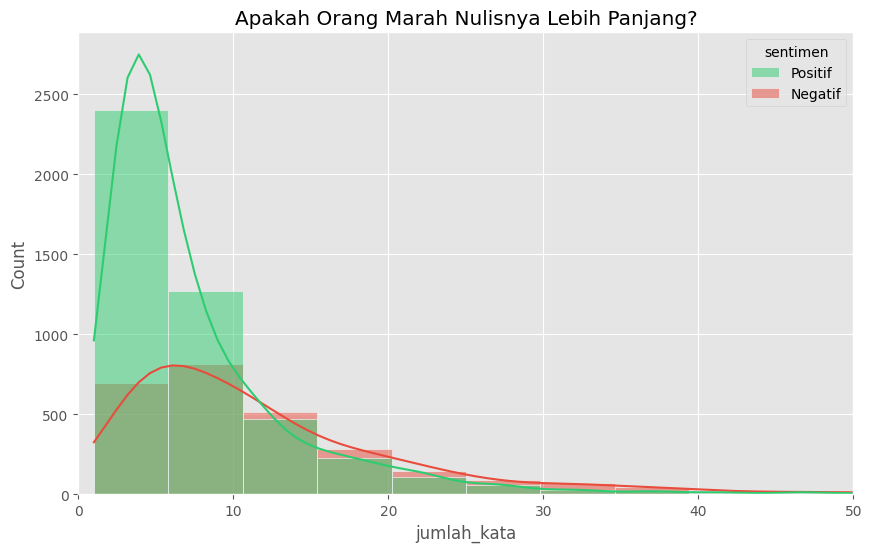

In [19]:
warna = {'Positif': '#2ecc71', 'Negatif': '#e74c3c'}

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='jumlah_kata', hue='sentimen', kde=True, palette=warna, bins=30)
plt.title('Apakah Orang Marah Nulisnya Lebih Panjang?')
plt.xlim(0, 50) # Fokus nang review sing wajar
plt.show()

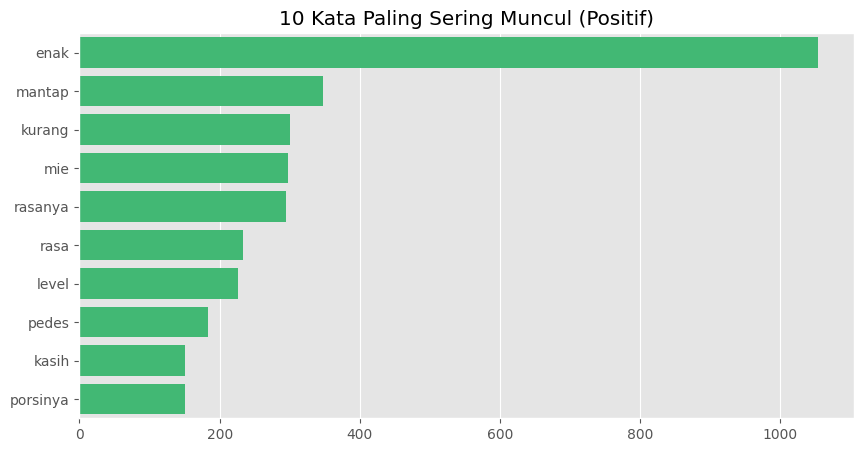

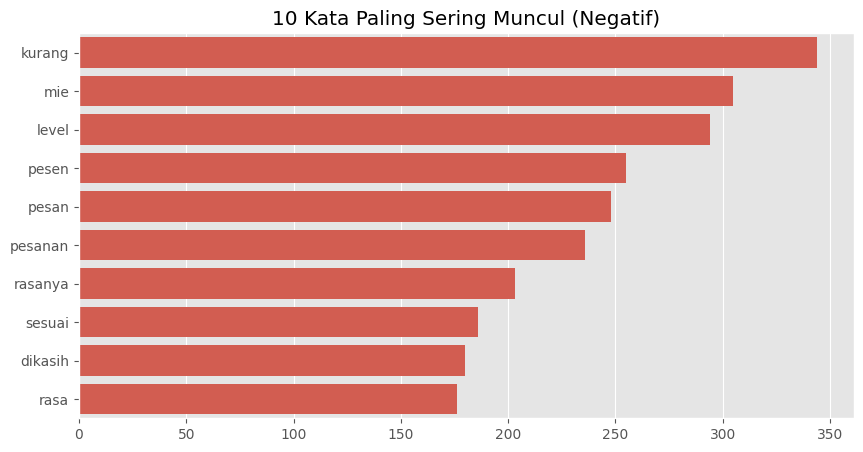

In [26]:
from collections import Counter

def plot_top_words(teks_list, judul, warna_bar):
    all_words = " ".join(str(t) for t in teks_list).lower().split()
    # Filter stopwords
    clean_words = [w for w in all_words if w not in stopwords_id and len(w) > 2]
    
    counter = Counter(clean_words)
    most_common = counter.most_common(10)
    
    words = [x[0] for x in most_common]
    counts = [x[1] for x in most_common]
    
    plt.figure(figsize=(10, 5))
    sns.barplot(x=counts, y=words, color=warna_bar)
    plt.title(judul)
    plt.show()

stopwords_id = set([
    'yg', 'yang', 'dan', 'ada', 'sama', 'di', 'ke', 'ini', 'itu', 'nya', 'untuk', 'dengan', 
    'dari', 'karena', 'kalau', 'tapi', 'saya', 'aku', 'bgt', 'banget', 'gak', 
    'tidak', 'lagi', 'ga', 'ya', 'malah', 'aja', 'sih', 'nya', 'udh', 'udah', 'sdh', 'sy', 'dr'
])

df_pos = df[df['sentimen'] == 'Positif']
df_neg = df[df['sentimen'] == 'Negatif']   
plot_top_words(df_pos['review'], "10 Kata Paling Sering Muncul (Positif)", "#2ecc71")
plot_top_words(df_neg['review'], "10 Kata Paling Sering Muncul (Negatif)", "#e74c3c")

# Preprocessing

In [27]:
# kamus
slang_dict = {
    "gak": "tidak", "ga": "tidak", "g": "tidak", "nggak": "tidak", "gk": "tidak",
    "yg": "yang", "bgt": "banget", "bgtt": "banget",
    "bs": "bisa", "bisaa": "bisa", "dgn": "dengan", "dr": "dari",
    "kalo": "kalau", "kl": "kalau", "jd": "jadi", "krn": "karena",
    "utk": "untuk", "tp": "tapi", "sy": "saya", "aku": "saya",
    "sdh": "sudah", "dah": "sudah", "blm": "belum",
    "thx": "terima kasih", "makasih": "terima kasih", "tks": "terima kasih",
    "uenak": "enak", "uenaaak": "enak", "enak": "enak",
    "mantul": "mantap", "mantap": "bagus", "best": "bagus", "good": "bagus",
    "bad": "buruk", "parah": "buruk", "kecewa": "buruk",
    "pesen": "pesan", "order": "pesan", "overprice": "mahal"
}

In [28]:
def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text) # Mung njupuk huruf
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]
    return " ".join(words)

In [29]:
df['review_clean'] = df['review'].apply(clean_text)

In [30]:
# pembobotan rating
rating_map = {1: -1.0, 2: -0.5, 3: 0.0, 4: 0.5, 5: 1.0}
df['score_rating'] = df['rating'].map(rating_map)

In [31]:
df.head()

,rating,review,sentimen,jumlah_kata,review_clean,score_rating
0,5.0,Alhamdulillah mantap,Positif,2,alhamdulillah bagus,1.0
1,5.0,Alhamdulillah mantap,Positif,2,alhamdulillah bagus,1.0
2,2.0,"Lama bgt, dan harusnya diproses dlu sblm drive...",Negatif,13,lama banget dan harusnya diproses dlu sblm dri...,-0.5
3,3.0,Request ayam paha atas malah di kasih ayam pah...,Negatif,10,request ayam paha atas malah di kasih ayam pah...,0.0
4,1.0,Sudah ditulis chili sauce tetap di campur toma...,Negatif,14,sudah ditulis chili sauce tetap di campur toma...,-1.0


In [33]:
# pembobotan teks
pos_list = set(['enak', 'sedap', 'mantap', 'bagus', 'cepat', 'ramah', 'bersih', 'murah', 'banyak', 'puas', 'suka', 'cinta', 'juara', 'terbaik', 'top', 'oke', 'ok', 'lezat', 'higienis', 'rapi'])
neg_list = set(['tidak', 'jangan', 'kurang', 'buruk', 'lama', 'mahal', 'kotor', 'sedikit', 'asin', 'hambar', 'pahit', 'mentah', 'basi', 'dingin', 'keras', 'gosong', 'kecewa', 'nyesel', 'kapok', 'salah', 'ancur', 'rusak'])

def hitung_bobot_teks(teks):
    words = teks.split()
    score = 0
    
    for i, word in enumerate(words):
        if word in pos_list:
            
            if i > 0 and words[i-1] in ['tidak', 'bukan', 'jangan']:
                score -= 1 # Jadi Negatif
            else:
                score += 1 # Positif
                
        elif word in neg_list:
            # Kata negatif tetep negatif
            score -= 1 
            
    # Normalisasi
    if len(words) > 0:
        norm_score = score / len(words) # Dibagi jumlah kata
    else:
        norm_score = 0
        
    return max(min(norm_score * 5, 1.0), -1.0)

In [34]:
df['score_text'] = df['review_clean'].apply(hitung_bobot_teks)

df.head()

,rating,review,sentimen,jumlah_kata,review_clean,score_rating,score_text
0,5.0,Alhamdulillah mantap,Positif,2,alhamdulillah bagus,1.0,1.000000
1,5.0,Alhamdulillah mantap,Positif,2,alhamdulillah bagus,1.0,1.000000
2,2.0,"Lama bgt, dan harusnya diproses dlu sblm drive...",Negatif,13,lama banget dan harusnya diproses dlu sblm dri...,-0.5,-0.769231
3,3.0,Request ayam paha atas malah di kasih ayam pah...,Negatif,10,request ayam paha atas malah di kasih ayam pah...,0.0,0.000000
4,1.0,Sudah ditulis chili sauce tetap di campur toma...,Negatif,14,sudah ditulis chili sauce tetap di campur toma...,-1.0,-0.357143


In [35]:
# gabung bobot rating dan teks
# Rumus: 60% Percaya Rating, 40% Percaya Teks
alpha = 0.6 
beta = 0.4

df['final_score'] = (alpha * df['score_rating']) + (beta * df['score_text'])

In [37]:
# labeling

def set_final_label(score):
    if score >= 0.05: return 1 # Positif
    else: return 0 # Negatif

df['label_hybrid'] = df['final_score'].apply(set_final_label)

df.head()

,rating,review,sentimen,jumlah_kata,review_clean,score_rating,score_text,final_score,label_hybrid
0,5.0,Alhamdulillah mantap,Positif,2,alhamdulillah bagus,1.0,1.000000,1.000000,1
1,5.0,Alhamdulillah mantap,Positif,2,alhamdulillah bagus,1.0,1.000000,1.000000,1
2,2.0,"Lama bgt, dan harusnya diproses dlu sblm drive...",Negatif,13,lama banget dan harusnya diproses dlu sblm dri...,-0.5,-0.769231,-0.607692,0
3,3.0,Request ayam paha atas malah di kasih ayam pah...,Negatif,10,request ayam paha atas malah di kasih ayam pah...,0.0,0.000000,0.000000,0
4,1.0,Sudah ditulis chili sauce tetap di campur toma...,Negatif,14,sudah ditulis chili sauce tetap di campur toma...,-1.0,-0.357143,-0.742857,0


In [38]:
# cek hasil
anomali = df[(df['rating'] == 5) & (df['label_hybrid'] == 0)]
if not anomali.empty:
    print(f"Ditemukan {len(anomali)} ulasan Bintang 5 tapi isine Komplain:")
    display(anomali[['rating', 'review', 'score_text', 'final_score', 'label_hybrid']].head())
else:
    print("Tidak ada anomali ekstrem.")

print("\nSeabaran Label Hybrid:")
print(df['label_hybrid'].value_counts(normalize=True))

Tidak ada anomali ekstrem.

Seabaran Label Hybrid:
label_hybrid
1    0.595264
0    0.404736
Name: proportion, dtype: float64


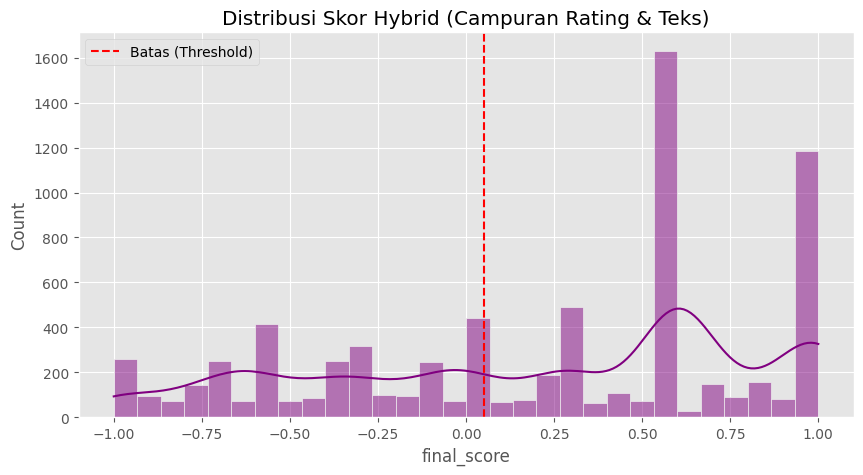

In [39]:
plt.figure(figsize=(10, 5))
sns.histplot(df['final_score'], kde=True, bins=30, color='purple')
plt.axvline(0.05, color='red', linestyle='dashed', label='Batas (Threshold)')
plt.title('Distribusi Skor Hybrid (Campuran Rating & Teks)')
plt.legend()
plt.show()

In [40]:
df.to_csv('data-sertimen-gofood.csv', index=False)

# Modelling (SVM)

In [41]:
df = df.dropna(subset=['review_clean', 'label_hybrid'])

In [42]:
X = df['review_clean']
y = df['label_hybrid']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Jumlah Data Latih: {len(X_train)}")
print(f"Jumlah Data Ujian: {len(X_test)}")

Jumlah Data Latih: 5912
Jumlah Data Ujian: 1478


Pipeline

In [45]:
pipeline = Pipeline([
    # vectorizer (tfidf)
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2), max_features=10000)),
    # classifier (svm)
    ('clf', LinearSVC(random_state=42, class_weight='balanced'))
])

Train

In [46]:
print("\nStart")
pipeline.fit(X_train, y_train)
print("Finish")


Start
Finish


In [51]:
# eval
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = pipeline.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)

print("\n" + "="*40)
print(f"Akurasi Model =  {akurasi * 100:.2f}%")
print("="*40)

print("\nLaporan Detail:")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Positif']))


Akurasi Model =  84.57%

Laporan Detail:
              precision    recall  f1-score   support

     Negatif       0.78      0.87      0.82       598
     Positif       0.90      0.83      0.87       880

    accuracy                           0.85      1478
   macro avg       0.84      0.85      0.84      1478
weighted avg       0.85      0.85      0.85      1478



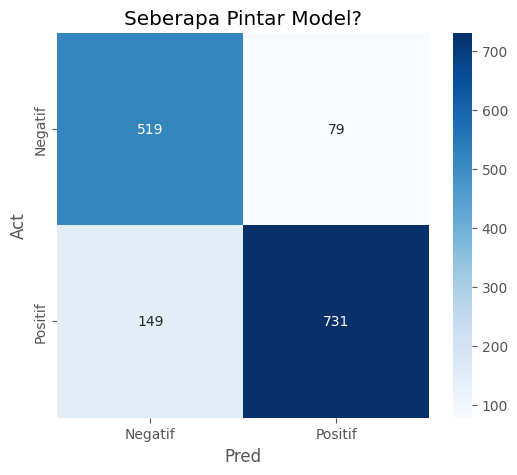

In [53]:
# confussion matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negatif', 'Positif'], yticklabels=['Negatif', 'Positif'])
plt.ylabel('Act')
plt.xlabel('Pred')
plt.title('Seberapa Pintar Model?')
plt.show()

In [55]:
# save model
nama_file_model = 'model_sentimen_hybrid.pkl'
with open(nama_file_model, 'wb') as f:
    pickle.dump(pipeline, f)
print(f"💾 Model sukses disimpan: '{nama_file_model}'")

💾 Model sukses disimpan: 'model_sentimen_hybrid.pkl'


In [57]:
# test

def tes(text):
    # Prediksi
    hasil = pipeline.predict([text])[0]
    
    # Keterangan
    if hasil == 1:
        return "POSITIF"
    else:
        return "NEGATIF"
    
kasus = [
    "Rasanya enak banget, nagih pol!", 
    "Pengiriman lama, makanan sampe dingin.",
    "Katanya pedas, tapi rasanya hambar, kecewa.", 
    "Lumayan lah buat ganjal perut.",
    "Tidak mengecewakan, mantap!", # Ujian N-Gram (Tidak + Mengecewakan)
    "Enak sih, tapi pelayanannya jutek." # Kalimat Campuran (Mixed)
]

for k in kasus:
    print(f"Review: '{k}' \n   -> Hasil: {tes(k)}\n")

Review: 'Rasanya enak banget, nagih pol!' 
   -> Hasil: POSITIF

Review: 'Pengiriman lama, makanan sampe dingin.' 
   -> Hasil: NEGATIF

Review: 'Katanya pedas, tapi rasanya hambar, kecewa.' 
   -> Hasil: NEGATIF

Review: 'Lumayan lah buat ganjal perut.' 
   -> Hasil: POSITIF

Review: 'Tidak mengecewakan, mantap!' 
   -> Hasil: POSITIF

Review: 'Enak sih, tapi pelayanannya jutek.' 
   -> Hasil: POSITIF

